In [1]:
import pandas as pd

In [11]:
vanilla = pd.read_csv("/home/gianfranco/projects/2025/Visual_Intelligence_Project/Mixture-of-Recursions-for-Vision/plot_wandb_csvs/vanilla_train_loss.csv")
token = pd.read_csv("/home/gianfranco/projects/2025/Visual_Intelligence_Project/Mixture-of-Recursions-for-Vision/plot_wandb_csvs/token_train_loss.csv")
random = pd.read_csv("/home/gianfranco/projects/2025/Visual_Intelligence_Project/Mixture-of-Recursions-for-Vision/plot_wandb_csvs/random_train_loss.csv")
balacing_entropy = pd.read_csv("/home/gianfranco/projects/2025/Visual_Intelligence_Project/Mixture-of-Recursions-for-Vision/plot_wandb_csvs/Balancing_entropy_token.csv")
balacing_loss = pd.read_csv("/home/gianfranco/projects/2025/Visual_Intelligence_Project/Mixture-of-Recursions-for-Vision/plot_wandb_csvs/Balancing_loss_token.csv")

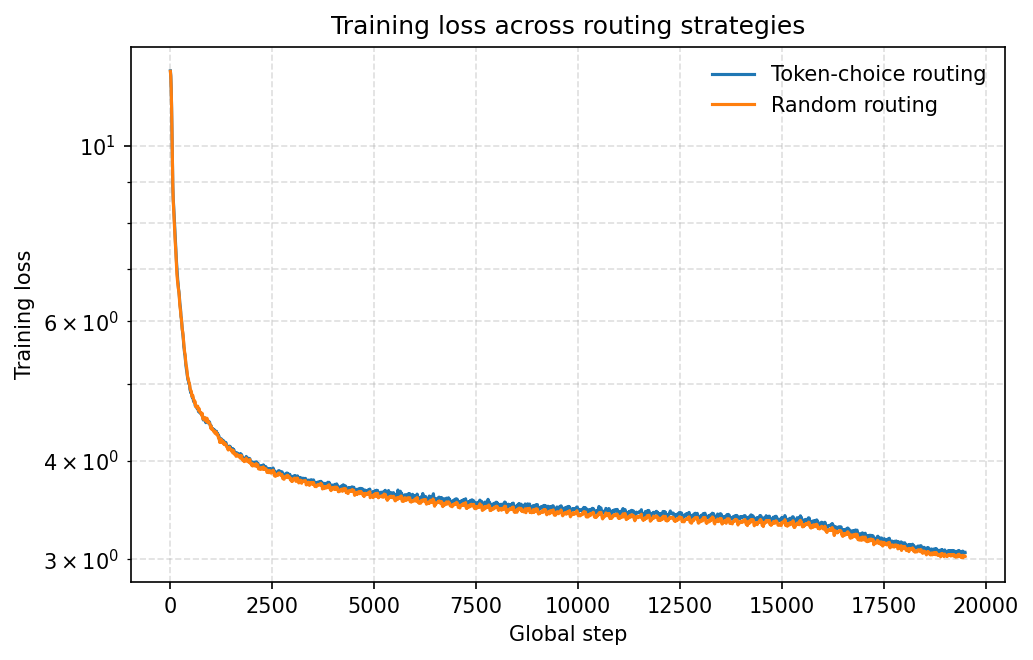

In [21]:
import matplotlib.pyplot as plt

# Column names
STEP_COL = "train/global_step"
VANILLA_LOSS = "vanilla_19500 - train/loss"
TOKEN_LOSS   = "smoke_19500steps_token - train/loss"
RANDOM_LOSS  = "MoR-SmolLM-135M-Random - train/loss"

# Optional: smooth noisy curves with a rolling mean (set WINDOW = 1 to disable)
WINDOW = 1

def smooth(df, col, w=WINDOW):
    return df[col].rolling(window=w, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)

#ax.plot(vanilla[STEP_COL], smooth(vanilla, VANILLA_LOSS),
#        label="Vanilla", linewidth=1.5)
ax.plot(token[STEP_COL],   smooth(token,   TOKEN_LOSS),
        label="Token-choice routing", linewidth=1.5)
ax.plot(random[STEP_COL],  smooth(random,  RANDOM_LOSS),
        label="Random routing", linewidth=1.5)

ax.set_xlabel("Global step")
ax.set_ylabel("Training loss")
ax.set_title("Training loss across routing strategies")
ax.set_yscale("log")          # remove if you want a linear y-axis
ax.grid(True, which="both", linestyle="--", alpha=0.4)
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig("train_loss_comparison.pdf", bbox_inches="tight")  # vector, good for reports
fig.savefig("train_loss_comparison.png", bbox_inches="tight", dpi=300)
plt.show()

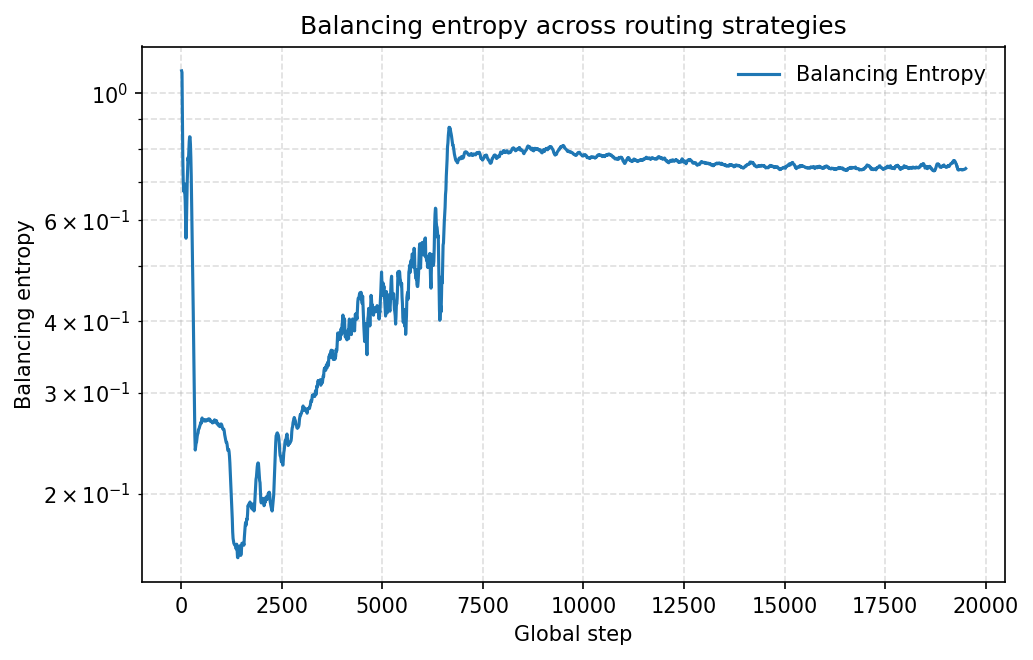

In [19]:
import matplotlib.pyplot as plt

# Column names
STEP_COL = "train/global_step"
BALANCING_ENTROPY = "smoke_19500steps_token - train/balancing_entropy"

WINDOW = 10

def smooth(df, col, w=WINDOW):
    return df[col].rolling(window=w, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)

ax.plot(balacing_entropy[STEP_COL], smooth(balacing_entropy, BALANCING_ENTROPY),
        label="Balancing Entropy", linewidth=1.5)


ax.set_xlabel("Global step")
ax.set_ylabel("Balancing entropy")
ax.set_title("Balancing entropy across routing strategies")
ax.set_yscale("log")          # remove if you want a linear y-axis
ax.grid(True, which="both", linestyle="--", alpha=0.4)
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig("balancing_entropy_comparison.pdf", bbox_inches="tight")  # vector, good for reports
fig.savefig("balancing_entropy_comparison.png", bbox_inches="tight", dpi=300)
plt.show()

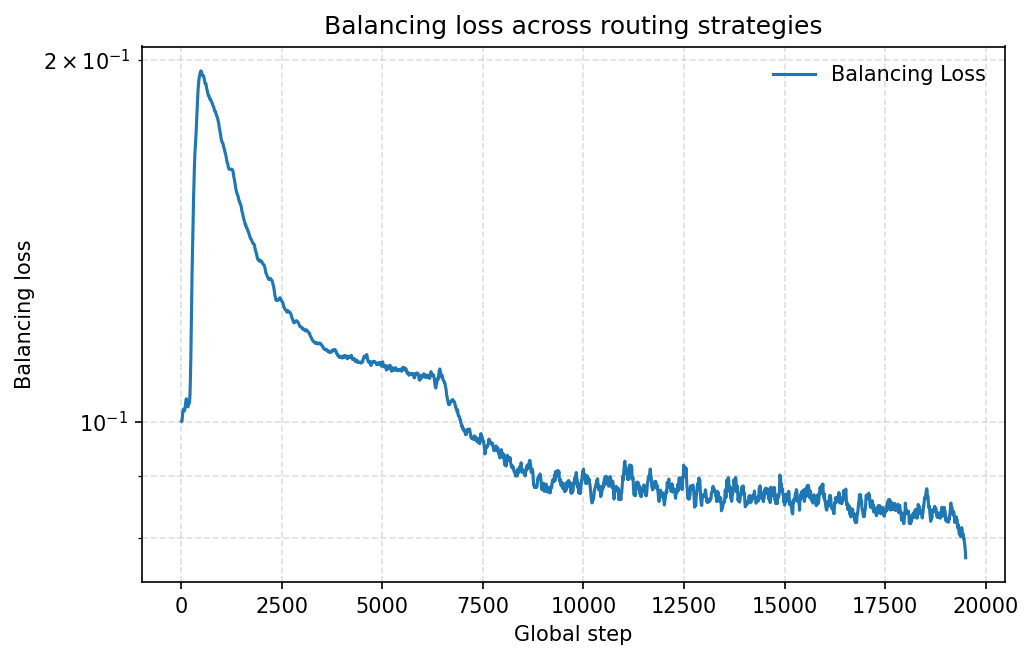

In [18]:
import matplotlib.pyplot as plt

# Column names
STEP_COL = "train/global_step"
BALANCING_LOSS = "smoke_19500steps_token - train/balancing_loss"

WINDOW = 10

def smooth(df, col, w=WINDOW):
    return df[col].rolling(window=w, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)

ax.plot(balacing_loss[STEP_COL], smooth(balacing_loss, BALANCING_LOSS),
        label="Balancing Loss", linewidth=1.5)


ax.set_xlabel("Global step")
ax.set_ylabel("Balancing loss")
ax.set_title("Balancing loss across routing strategies")
ax.set_yscale("log")          # remove if you want a linear y-axis
ax.grid(True, which="both", linestyle="--", alpha=0.4)
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig("balancing_loss_comparison.pdf", bbox_inches="tight")  # vector, good for reports
fig.savefig("balancing_loss_comparison.png", bbox_inches="tight", dpi=300)
plt.show()